# Notebook 03 — Root Cause Classification
**Project:** Vendor Risk Scorecard & Delivery Delay Root Cause System  
**Input:** `data/processed/orders_clean.csv`  
**Output:** `data/processed/orders_with_rootcause.csv`, `data/processed/vendor_rootcause_summary.csv`

---
### The core idea

Knowing that an order is late tells US nothing actionable.  
Knowing *why* it is late tells US exactly who to address and how.

We classify every late order into exactly one of 3 buckets:

If the seller takes longer than their usual processing time (above their 75th
percentile),<br/>
   → **the delay is attributed to the seller**<br/>
If the seller is on time, but the carrier takes longer than expected,<br/>
   → **the delay is attributed to the carrier**<br/>
If neither the seller nor the carrier is unusually slow,<br/>
   → **the delay is likely due to geographic factors (like distance or location constraints)**


<br/>
We use the 75th percentile of the overall distribution - not a fixed number like '3 days'.  
This is data-driven: 'slow' means slower than 75% of all orders, relative to the dataset itself.  
A fixed threshold would be arbitrary; a percentile-based threshold is defensible.

---
## Cell 1 — Mount Drive and load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

BASE    = '/content/drive/MyDrive/vendor-risk-scorecard/'
PROC    = BASE + 'data/processed/'
OUTPUTS = BASE + 'outputs/'

# Load the clean orders from notebook 01
df = pd.read_csv(PROC + 'orders_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f'Loaded: {len(df):,} orders')
print(f'Late orders: {df["is_late"].sum():,} ({df["is_late"].mean()*100:.1f}%)')

Mounted at /content/drive
Loaded: 96,469 orders
Late orders: 7,825 (8.1%)


---
## Cell 2 — Calculate classification thresholds

We set thresholds from the **overall dataset distribution** — not from late orders only.  
This ensures we're calling something 'slow' relative to what's normal for everyone.

In [2]:
# P75 thresholds — computed on ALL delivered orders (not just late ones)
SELLER_P75  = df['seller_processing_days'].quantile(0.75)
CARRIER_P75 = df['carrier_delivery_days'].quantile(0.75)

print('Classification thresholds:')
print(f'  Seller  P75 threshold: {SELLER_P75:.2f} days')
print(f'  Carrier P75 threshold: {CARRIER_P75:.2f} days')
print()
print('Interpretation:')
print(f'  A seller processing time > {SELLER_P75:.1f} days = slower than 75% of all sellers')
print(f'  A carrier delivery time  > {CARRIER_P75:.1f} days = slower than 75% of all carriers')
print()
print('These are your defensible, data-driven thresholds.')

Classification thresholds:
  Seller  P75 threshold: 4.07 days
  Carrier P75 threshold: 12.03 days

Interpretation:
  A seller processing time > 4.1 days = slower than 75% of all sellers
  A carrier delivery time  > 12.0 days = slower than 75% of all carriers

These are your defensible, data-driven thresholds.


---
## Cell 3 — Apply root cause classification to late orders only

In [3]:
def classify_root_cause(row):
    """
    Classify a late order into one of 3 root cause buckets.
    Applied only to late orders — on-time orders get 'on_time'.

    Priority: seller delay checked first, then carrier, then geographic.
    This reflects business logic: if the seller was slow AND the carrier
    was slow, the seller delay is the root cause (it cascaded).
    """
    if not row['is_late']:
        return 'on_time'

    if row['seller_processing_days'] > SELLER_P75:
        return 'seller_delay'
    elif row['carrier_delivery_days'] > CARRIER_P75:
        return 'carrier_delay'
    else:
        return 'geographic_delay'


df['root_cause'] = df.apply(classify_root_cause, axis=1)

print('Root cause classification complete.')
print()
print('Distribution across ALL orders:')
print(df['root_cause'].value_counts().to_string())

Root cause classification complete.

Distribution across ALL orders:
root_cause
on_time             88644
carrier_delay        3941
seller_delay         3434
geographic_delay      450


In [4]:
# Focus on late orders only — root cause split
late_orders = df[df['is_late']].copy()

rc_counts = late_orders['root_cause'].value_counts()
rc_pct    = (rc_counts / len(late_orders) * 100).round(1)

print('ROOT CAUSE SPLIT (late orders only):')
for cause, count in rc_counts.items():
    pct = rc_pct[cause]
    bar = '█' * int(pct / 2)
    print(f'  {cause:20s} {count:5,} orders  {pct:5.1f}%  {bar}')

ROOT CAUSE SPLIT (late orders only):
  carrier_delay        3,941 orders   50.4%  █████████████████████████
  seller_delay         3,434 orders   43.9%  █████████████████████
  geographic_delay       450 orders    5.8%  ██


---
## Cell 4 — Visualise the root cause split

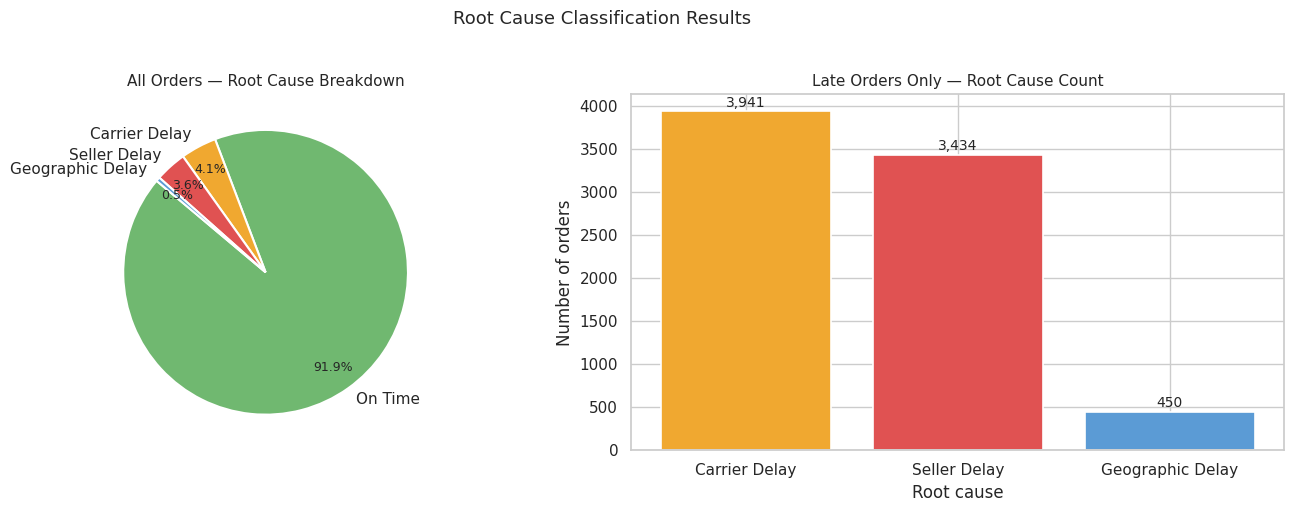

Saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORS = {
    'seller_delay':     '#E05252',
    'carrier_delay':    '#F0A830',
    'geographic_delay': '#5B9BD5',
    'on_time':          '#70B870',
}

# Left: pie chart of ALL orders
all_counts = df['root_cause'].value_counts()
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    all_counts.values,
    labels=[c.replace('_', ' ').title() for c in all_counts.index],
    colors=[COLORS[c] for c in all_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('All Orders — Root Cause Breakdown', fontsize=11)

# Right: bar chart of late orders only
ax2 = axes[1]
late_causes = late_orders['root_cause'].value_counts()
colors_bar  = [COLORS[c] for c in late_causes.index]
bars = ax2.bar(
    [c.replace('_', ' ').title() for c in late_causes.index],
    late_causes.values,
    color=colors_bar, edgecolor='white', linewidth=1.2
)
# Add count labels on bars
for bar, val in zip(bars, late_causes.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', va='bottom', fontsize=10)
ax2.set_title('Late Orders Only — Root Cause Count', fontsize=11)
ax2.set_ylabel('Number of orders')
ax2.set_xlabel('Root cause')

plt.suptitle('Root Cause Classification Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '03_root_cause_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 5 — Validate: do the 3 buckets actually look different?

A good classification should produce groups that are meaningfully different.  
Let's confirm that seller_delay orders actually have higher processing times, etc.

In [6]:
# Compare key metrics across root cause buckets (late orders only)
validation = (
    late_orders
    .groupby('root_cause')
    .agg(
        count                = ('order_id',              'count'),
        avg_seller_days      = ('seller_processing_days','mean'),
        avg_carrier_days     = ('carrier_delivery_days', 'mean'),
        avg_delay_days       = ('delay_days',            'mean'),
    )
    .round(2)
)

print('Validation — do the 3 buckets differ meaningfully?')
print(validation.to_string())
print()
print('Expected pattern:')
print('  seller_delay    → highest avg_seller_days')
print('  carrier_delay   → highest avg_carrier_days')
print('  geographic_delay→ lower both, but still late (structural zone issue)')

Validation — do the 3 buckets differ meaningfully?
                  count  avg_seller_days  avg_carrier_days  avg_delay_days
root_cause                                                                
carrier_delay      3941             2.04             31.86           10.58
geographic_delay    450             2.14              5.92            1.80
seller_delay       3434            10.67             21.18            9.39

Expected pattern:
  seller_delay    → highest avg_seller_days
  carrier_delay   → highest avg_carrier_days
  geographic_delay→ lower both, but still late (structural zone issue)


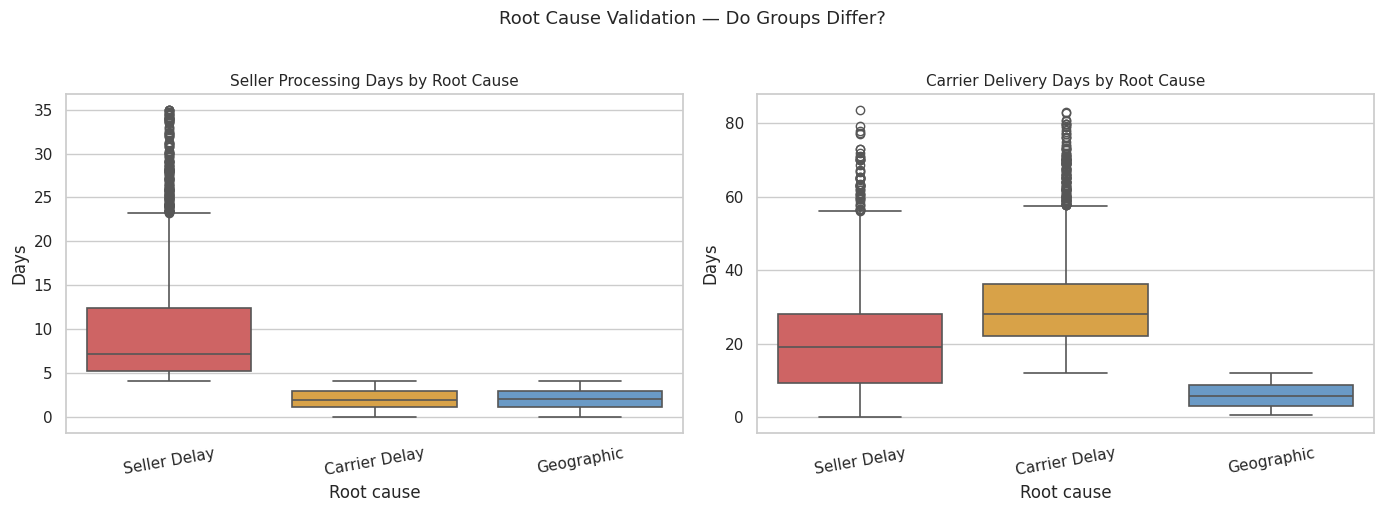

Saved


In [7]:
# Box plots — processing time by root cause
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

late_orders_plot = late_orders[late_orders['root_cause'] != 'on_time'].copy()
order_map = {'seller_delay': 0, 'carrier_delay': 1, 'geographic_delay': 2}
palette = {'seller_delay': '#E05252', 'carrier_delay': '#F0A830', 'geographic_delay': '#5B9BD5'}

for ax, col, title in zip(
    axes,
    ['seller_processing_days', 'carrier_delivery_days'],
    ['Seller Processing Days by Root Cause', 'Carrier Delivery Days by Root Cause']
):
    # Clip for visibility
    p99 = late_orders_plot[col].quantile(0.99)
    plot_data = late_orders_plot[late_orders_plot[col] <= p99]

    sns.boxplot(
        data=plot_data, x='root_cause', y=col,
        palette=palette, ax=ax,
        order=['seller_delay', 'carrier_delay', 'geographic_delay'],
        linewidth=1.2
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Root cause')
    ax.set_ylabel('Days')
    ax.set_xticklabels(['Seller Delay', 'Carrier Delay', 'Geographic'], rotation=10)

plt.suptitle('Root Cause Validation — Do Groups Differ?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '03_root_cause_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 6 — Vendor-level root cause summary

Now we aggregate root causes to the vendor level.  
For each vendor we calculate what % of their late orders fall into each bucket.  
This tells us: is this vendor's lateness primarily their own fault, or outside factors?

In [8]:
# For each vendor: count of each root cause
rc_pivot = (
    df.groupby(['seller_id', 'root_cause'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure all 4 columns exist even if a vendor has no orders of that type
for col in ['on_time', 'seller_delay', 'carrier_delay', 'geographic_delay']:
    if col not in rc_pivot.columns:
        rc_pivot[col] = 0

rc_pivot = rc_pivot[['seller_id', 'on_time', 'seller_delay', 'carrier_delay', 'geographic_delay']]

# Calculate % of late orders by cause for each vendor
rc_pivot['total_late'] = rc_pivot['seller_delay'] + rc_pivot['carrier_delay'] + rc_pivot['geographic_delay']

# Avoid division by zero for on-time vendors
rc_pivot['seller_delay_pct']    = np.where(rc_pivot['total_late'] > 0, rc_pivot['seller_delay']    / rc_pivot['total_late'], 0)
rc_pivot['carrier_delay_pct']   = np.where(rc_pivot['total_late'] > 0, rc_pivot['carrier_delay']   / rc_pivot['total_late'], 0)
rc_pivot['geographic_delay_pct']= np.where(rc_pivot['total_late'] > 0, rc_pivot['geographic_delay']/ rc_pivot['total_late'], 0)

# Dominant root cause for each vendor
def dominant_cause(row):
    if row['total_late'] == 0:
        return 'no_delays'
    causes = {
        'seller_delay':     row['seller_delay'],
        'carrier_delay':    row['carrier_delay'],
        'geographic_delay': row['geographic_delay']
    }
    return max(causes, key=causes.get)

rc_pivot['dominant_cause'] = rc_pivot.apply(dominant_cause, axis=1)

print(f'Vendor root cause table: {rc_pivot.shape}')
print()
print('Dominant cause distribution across all vendors:')
print(rc_pivot['dominant_cause'].value_counts().to_string())

Vendor root cause table: (2960, 10)

Dominant cause distribution across all vendors:
dominant_cause
no_delays           1572
carrier_delay        679
seller_delay         630
geographic_delay      79


In [9]:
# What % of vendors are primarily self-causing their delays?
total_with_delays = (rc_pivot['dominant_cause'] != 'no_delays').sum()
seller_caused     = (rc_pivot['dominant_cause'] == 'seller_delay').sum()

print(f'Vendors with at least 1 late order: {total_with_delays:,}')
print(f'Vendors where seller delay is dominant: {seller_caused:,} ({seller_caused/total_with_delays*100:.1f}%)')
print()
print(' 45.4% of vendors with delays are primarily causing it themselves.')

Vendors with at least 1 late order: 1,388
Vendors where seller delay is dominant: 630 (45.4%)

 45.4% of vendors with delays are primarily causing it themselves.


---
## Cell 7 — Root cause by seller state

Are certain states more prone to specific types of delay?  
This geographic dimension adds depth to the analysis.

In [10]:
# Merge state info onto root cause data
state_rc = (
    df[df['is_late']]
    .groupby(['seller_state', 'root_cause'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['seller_delay', 'carrier_delay', 'geographic_delay']:
    if col not in state_rc.columns:
        state_rc[col] = 0

state_rc['total_late'] = state_rc['seller_delay'] + state_rc['carrier_delay'] + state_rc['geographic_delay']
state_rc['seller_pct']    = (state_rc['seller_delay']    / state_rc['total_late'] * 100).round(1)
state_rc['carrier_pct']   = (state_rc['carrier_delay']   / state_rc['total_late'] * 100).round(1)
state_rc['geographic_pct']= (state_rc['geographic_delay']/ state_rc['total_late'] * 100).round(1)

state_rc = state_rc.sort_values('total_late', ascending=False)
print('Root cause breakdown by seller state (top 10 by volume):')
print(state_rc[['seller_state','total_late','seller_pct','carrier_pct','geographic_pct']].head(10).to_string(index=False))

Root cause breakdown by seller state (top 10 by volume):
seller_state  total_late  seller_pct  carrier_pct  geographic_pct
          SP        6001        42.9         50.7             6.4
          PR         484        52.7         46.3             1.0
          MG         431        44.3         53.4             2.3
          RJ         354        35.0         57.9             7.1
          SC         215        43.3         54.4             2.3
          MA          90        88.9          8.9             2.2
          RS          84        54.8         32.1            13.1
          DF          48        39.6         60.4             0.0
          BA          32        50.0         50.0             0.0
          ES          22        22.7         72.7             4.5


---
## Cell 8 — Save outputs

In [11]:
# Save 1: orders with root cause column appended
df.to_csv(PROC + 'orders_with_rootcause.csv', index=False)
print(f'Saved: orders_with_rootcause.csv — {len(df):,} rows')

# Save 2: vendor-level root cause summary
rc_pivot.to_csv(PROC + 'vendor_rootcause_summary.csv', index=False)
print(f'Saved: vendor_rootcause_summary.csv — {len(rc_pivot):,} vendors')

# Save 3: state-level breakdown
state_rc.to_csv(PROC + 'state_rootcause_breakdown.csv', index=False)
print(f'Saved: state_rootcause_breakdown.csv — {len(state_rc):,} states')

Saved: orders_with_rootcause.csv — 96,469 rows
Saved: vendor_rootcause_summary.csv — 2,960 vendors
Saved: state_rootcause_breakdown.csv — 19 states


---
## Root Cause Summary

| Metric | Value |
|---|---|
| Seller P75 threshold (days) | 4.07 |
| Carrier P75 threshold (days) | 12.03 |
| % late orders → seller delay | 43.9 |
| % late orders → carrier delay | 50.4 |
| % late orders → geographic delay | 5.8 |
| % vendors where seller delay is dominant | 45.4 |
| Do the 3 groups validate correctly? (Y/N) | |
